In [23]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

# load CSV
df = pd.read_csv("three_noisy_signals.csv")

# rebuild time
t = df["time"].values

# recreate TRUE global temperature (original sine wave)
global_temperature = np.sin(2 * np.pi * 0.5 * t)

# add to dataframe
df["global_temperature"] = global_temperature

# input noisy sensors
X_raw = df[["signal2_noisy", "signal3_noisy", "signal4_noisy"]].values

# mask: 1 = observed, 0 = missing
mask = (~np.isnan(X_raw)).astype(float)

# fill missing values with column means
col_means = np.nanmean(X_raw, axis=0)
X_filled = np.where(np.isnan(X_raw), col_means, X_raw)

# add mask channels
X_model = np.concatenate([X_filled, mask], axis=1)

# target
y_raw = df["global_temperature"].values

# reshape
X = X_model[np.newaxis, :, :]          # (1, 200, 6)
y = y_raw[np.newaxis, :, np.newaxis]   # (1, 200, 1)

# normalize
X_mean = X.mean()
X_std = X.std()

y_mean = y.mean()
y_std = y.std()

X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

print(np.isnan(X_norm).sum())
print(np.isnan(y_norm).sum())
print(X_norm.shape, y_norm.shape)

0
0
(1, 200, 6) (1, 200, 1)


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed, Input

model = Sequential()

model.add(Input(shape=(X_norm.shape[1], X_norm.shape[2])))

model.add(
    LSTM(
        units=64,
        return_sequences=True
    )
)

model.add(TimeDistributed(Dense(1)))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 200, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 200, 1)         │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    X_norm,
    y_norm,
    epochs=200,
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - loss: 1.0277
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.9787
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.9344
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.8939
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.8564
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.8212
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.7877
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.7554
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.7237
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.6922
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.6605
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.6281
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.5947
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.5599
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.5234
Epoch 16/200


In [30]:
y_pred_norm = model.predict(X_norm)

# convert back to original scale
y_pred = y_pred_norm * y_std + y_mean

print("Prediction shape:", y_pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction shape: (1, 200, 1)


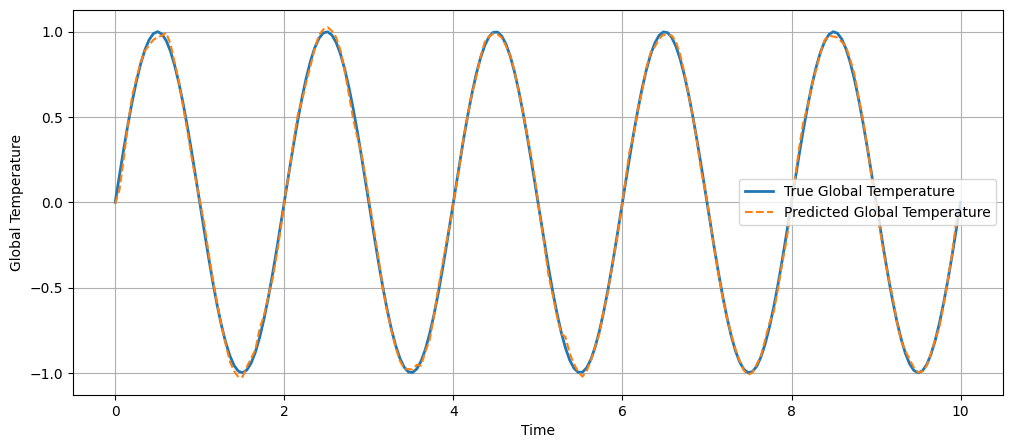

In [31]:
import matplotlib.pyplot as plt

t = df["time"].values

plt.figure(figsize=(12, 5))
plt.plot(t, y[0, :, 0], label="True Global Temperature", linewidth=2)
plt.plot(t, y_pred[0, :, 0], label="Predicted Global Temperature", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Global Temperature")
plt.legend()
plt.grid(True)
plt.show()